# Modelling a circumbinary dust rim with HMC

This tutorial walks through parametric modelling of a circumbinary dust rim using
a chromatic model with an azmiuthally modulated Gaussian rim. For this we'll be using
the VLTI/PIONIER dataset of [Hillen et al. 2016](http://dx.doi.org/10.1051/0004-6361/201628125),
where they target the circumbinary disk surrounding the evolved post-AGB binary 
IRAS 08544-443.

First, let's import everything we will need.

In [1]:
from pathlib import Path

import anesthetic
import blackjax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import tqdm
from blackjax.ns.utils import finalise
from jax.tree_util import Partial
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import ImageGrid, make_axes_locatable

from drpangloss._utils import RAD2DEG, dict_merge_az_amp_and_az_pa
from drpangloss.models import BinaryGaussianRimModel, OIData, loglike

## Loading data

The dataset consists of multiple OIFITS files. We'll be reading these into a `OIData`
object, which `drpangloss` uses to handle data. The PIONIER data consists of squared 
visibilities ($V^2$) and closure phases ($\phi3$) for six different wavelength channels. 

In [2]:
# Path to directory with OIFITS files.
ddir = Path("../data/IRAS08544-4431_PIONIER/")
file_list = list(ddir.glob("*.fits"))
oidata = OIData(file_list)

### Plotting to check the loaded data.

Below, we extract some useful quantities to make some diagnostic plots of our data,
just to see if all data has been read in properly and if we can alreay glean something
about the target structure from the data. To have a good look at the spatial and 
chromatic structure of the target, we'll be plotting the $V^2$ data and $\phi3$ data
as a function of observed spatial frequency (using the longest baseline per closure
triangle for the $\phi3$ data), and color-coding everything by wavelength $\lambda$.

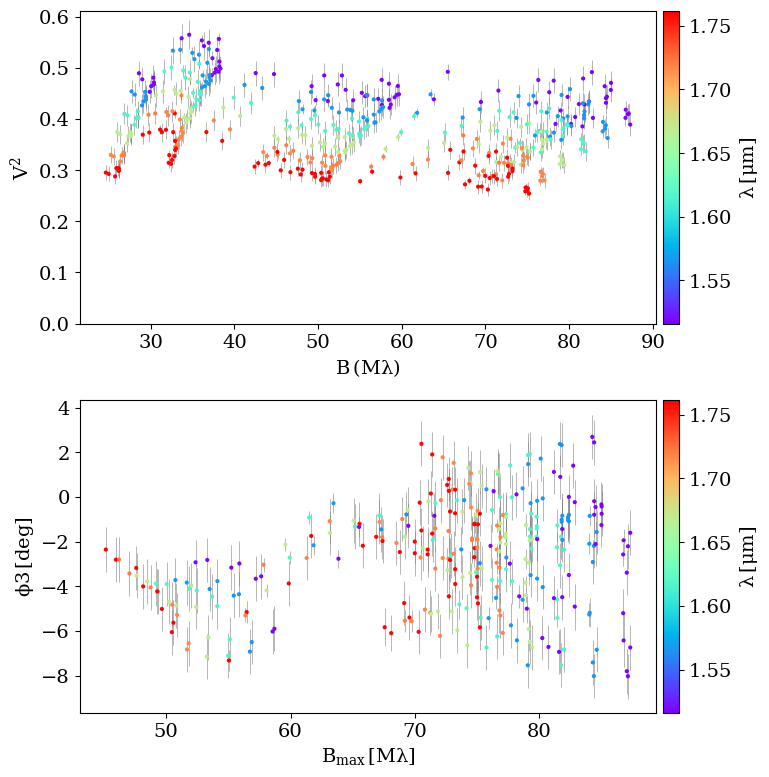

In [3]:
def plot_data(oidata):
    # Observed squared visibilities data per observed spatial freuqency.
    obs_vis2 = oidata.vis
    obs_d_vis2 = oidata.d_vis
    obs_vis2_wavel = (
        oidata.wavel
    )  # Wavelength per observed squared visibility.
    # Spatial frequencies per baseline.
    obs_uf = oidata.u / oidata.wavel
    obs_vf = oidata.v / oidata.wavel
    obs_base = jnp.hypot(oidata.u, oidata.v)
    obs_basef = jnp.hypot(obs_uf, obs_vf)  # Norm of spatial frequency.

    # Observed closure phases per closure triangle in frequency space.
    obs_cp = oidata.phi
    obs_d_cp = oidata.d_phi
    obs_cp_wavel = obs_vis2_wavel[
        oidata.i_cps1
    ]  # Wavelength per observed closure phase.

    # Get max baseline norm for the baseline closure triangles.
    obs_base1 = obs_base[oidata.i_cps1]
    obs_base2 = obs_base[oidata.i_cps2]
    obs_base3 = obs_base[oidata.i_cps3]
    obs_basemaxf = jnp.maximum(
        obs_base1 / obs_cp_wavel,
        jnp.maximum(obs_base2 / obs_cp_wavel, obs_base3 / obs_cp_wavel),
    )

    fig, axes = plt.subplots(2, 1, figsize=(8, 8))

    # Squared visibility data.
    axes[0].errorbar(
        obs_basef / 1e6,
        obs_vis2,
        obs_d_vis2,
        fmt=",",
        elinewidth=0.4,
        ecolor="grey",
        zorder=-1,
    )
    sc1 = axes[0].scatter(
        obs_basef / 1e6, obs_vis2, c=obs_vis2_wavel * 1e6, s=4, cmap="rainbow"
    )

    # Closure phase data.
    axes[1].errorbar(
        obs_basemaxf / 1e6,
        obs_cp,
        obs_d_cp,
        fmt=",",
        elinewidth=0.4,
        ecolor="grey",
        zorder=-1,
    )
    sc2 = axes[1].scatter(
        obs_basemaxf / 1e6, obs_cp, c=obs_cp_wavel * 1e6, s=4, cmap="rainbow"
    )

    fig.colorbar(
        sc1, ax=axes[0], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
    )
    fig.colorbar(
        sc2, ax=axes[1], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
    )

    axes[0].set_ylim(0)
    axes[0].set_ylabel(r"$V^2$")
    axes[0].set_xlabel(r"$B \, (\mathregular{M\lambda})$")

    axes[1].set_ylabel(r"$\phi 3 \, [\mathregular{deg}]$")
    axes[1].set_xlabel(r"$B_{\mathregular{max}} \, [\mathregular{M\lambda}]$")

    plt.tight_layout()
    plt.show()


plot_data(oidata)

As we can see, the visibilities show some Bessel-like oscillations around a $V^2$ plateau.
This is indicative of some ring-like structure surrounding a central un- or marginally-resolved
object (which in this case is the primary star). There is also clearly a chromatic effect
where the level of the plateau strongly decreases at longer wavelengths, indicating that at these
wavelengths the total flux of the central star contributes less. The $\phi3$ data are a bit
harder to interpret per triangle, but are clearly non-zero, which indicates some asymmetry 
in the intensity of the distribution. This is a combination of the presence of the binary 
companion, an offset of the central star relative to the disk rim, or azimuthal 
modulations of the disk rim itself! We'll model all these effects below.


## Defining a chromatic circumbinary disk model

Below, we'll recreate the [Hillen et al. 2016](http://dx.doi.org/10.1051/0004-6361/201628125) model
used for the system. There are some differences though, including the use of spectral indices 
($d$ if $F_{\lambda} \propto (\lambda / \lambda_0)^d$) instead of blackbody temperatures 
to define the spectral behaviour. We also do not fit any chromaticity to the overresolved
background and secondary star.

The model consists of a chromatic point source for the primary, a chromatic azimuthally
modulated Gaussian disk rim and a grey companion point source and overresolved flux.
This model is implemented in the `BinaryGaussianRimModel` class.
Feel free to play around a little with the parameters and see how things change.

In [4]:
# Recreation of the Hillen et al. 2016 (A&A 588, L1) model. Differences include that the
# primary star is not in Rayleigh-Jeans regime (instead `si_p` is taken from a power-law
# fit to the synthetic H-band SED fit spectrum). `si_rim` (derived from the blackbody
# temperature found in the paper) has been corrected accordingly.
model_params = {
    "flux_p": 0.597,  # Total flux fraction of the primary.
    "ud_p": 0.5,  # Uniform disk diameter in milliarceseconds.
    "dra_p": 0.0,  # Primary right ascension offset in milliarcseconds.
    "ddec_p": 0.0,  # Primary declination offset in milliarcseconds.
    "si_p": -3.166,  # Spectral index of the primary.
    "flux_s": 0.039,  # Secondary flux fraction.
    "dra_s": -0.5,  # Secondary right ascension offset in milliarcseconds.
    "ddec_s": -0.7,  # Secondary declination offset in milliarcseconds.
    "si_s": 0.0,
    "diam_rim": 14.15,  # Diameter of the rim in milliarcseconds.
    "fwhm_rim": 3.233,  # Gaussian FWHM of the rim in milliarcseconds.
    "inc_rim": 19.0,  # Inclination of the rim in degrees.
    "pa_rim": 6.0,  # Position angle of the rim in degrees.
    "si_rim": 3.6,  # Rim spectral indexobs_vis2_i (from paper T_bb & modified for 'si_p' value).
    "flux_bkg": 0.155,  # Overresolved background flux fraction.
    "si_bkg": 0.0,
    "az_amps": [
        0.43011627,
        0.2745906,
    ],  # 1st & 2nd rim azimuthal modulation amplitudes (the paper worked with equivalent coefficients).
    "az_pas": [
        35.537678 + 6.0,
        50.245735 + 6.0,
    ],  # 1st & 2nd rim azimuthal modulation offset angles relative to 'pa_rim' in degrees.
    "wave0": 1.65e-6,  # Wavelength at which the flux fractions are defined in meter (not a free parameter).
}

model = BinaryGaussianRimModel(**model_params)

### Visualising the model morphology

The model also includes a model function to calculate an image of the modelled Gaussian 
rim. Note that this is purely for display and visual inspection purposes though. For this
model, the image is not actually used to calculate the predicted model observables (which
in this case are fully analytical).

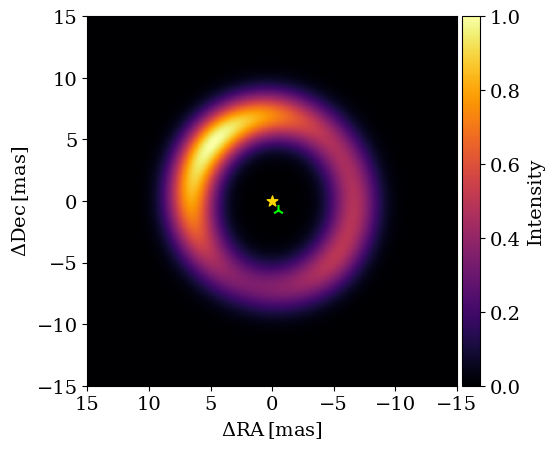

In [5]:
NPIX = 300  # Number of pixels along the field-of-view.
PS = 0.1  # Pixelscale in milliarcseconds.
FOV = NPIX * PS

# Get an image of the rim (normalized so sum of pixels is one).
rim_img = model.get_img(npix=NPIX, ps=PS)

fig, ax = plt.subplots(1, 1)
# Plot image.
im = ax.imshow(
    rim_img / jnp.max(rim_img),
    extent=(
        FOV / 2,
        -FOV / 2,
        -FOV / 2,
        FOV / 2,
    ),
    cmap="inferno",
)
# Add stars
ax.scatter(model.dra_p, model.ddec_p, marker="*", s=64, color="gold")
ax.scatter(model.dra_s, model.ddec_s, marker="2", s=64, color="lime")


# Add colorbar to the side.
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, label="Intensity")

ax.set_xlabel(r"$\Delta \mathregular{RA} \, \mathregular{[mas]}$")
ax.set_ylabel(r"$\Delta \mathregular{Dec} \, \mathregular{[mas]}$")

plt.show()

### Visualising the predicted model observables

Let's see what our current model predicts for the $V^2$ and $\phi3$ observables, and how
it holds up against the observed data. You'll see that we're not quite there yet
in terms of having a good fit to the data.

In [6]:
def plot_observable_predicitons_model(oidata, model):
    # Model predictions.
    oi_pred = oidata.model(model)
    mod_vis2 = oi_pred[: jnp.size(oidata.vis)]
    mod_cp = oi_pred[jnp.size(oidata.vis) :]

    # Observed squared visibilities data per observed spatial freuqency.
    obs_vis2 = oidata.vis
    obs_d_vis2 = oidata.d_vis
    obs_vis2_wavel = (
        oidata.wavel
    )  # Wavelength per observed squared visibility.
    # Spatial frequencies per baseline.
    obs_uf = oidata.u / oidata.wavel
    obs_vf = oidata.v / oidata.wavel
    obs_base = jnp.hypot(oidata.u, oidata.v)
    obs_basef = jnp.hypot(obs_uf, obs_vf)  # Norm of spatial frequency.

    # Observed closure phases per closure triangle in frequency space.
    obs_cp = oidata.phi
    obs_d_cp = oidata.d_phi
    obs_cp_wavel = obs_vis2_wavel[
        oidata.i_cps1
    ]  # Wavelength per observed closure phase.

    # Get max baseline norm for the baseline closure triangles.
    obs_base1 = obs_base[oidata.i_cps1]
    obs_base2 = obs_base[oidata.i_cps2]
    obs_base3 = obs_base[oidata.i_cps3]
    obs_basemaxf = jnp.maximum(
        obs_base1 / obs_cp_wavel,
        jnp.maximum(obs_base2 / obs_cp_wavel, obs_base3 / obs_cp_wavel),
    )

    fig, axes = plt.subplots(2, 1, figsize=(8, 8))

    # Squared visibility data.
    axes[0].errorbar(
        obs_basef / 1e6,
        obs_vis2,
        obs_d_vis2,
        fmt=",",
        elinewidth=0.4,
        ecolor="grey",
        zorder=-1,
    )
    sc1 = axes[0].scatter(
        obs_basef / 1e6, obs_vis2, c=obs_vis2_wavel * 1e6, s=4, cmap="rainbow"
    )
    axes[0].scatter(
        obs_basef / 1e6, mod_vis2, c="k", s=4, zorder=-1, marker="."
    )

    # Closure phase data.
    axes[1].errorbar(
        obs_basemaxf / 1e6,
        obs_cp,
        obs_d_cp,
        fmt=",",
        elinewidth=0.4,
        ecolor="grey",
        zorder=-1,
    )
    sc2 = axes[1].scatter(
        obs_basemaxf / 1e6, obs_cp, c=obs_cp_wavel * 1e6, s=4, cmap="rainbow"
    )
    axes[1].scatter(
        obs_basemaxf / 1e6, mod_cp, c="k", s=4, zorder=-1, marker="."
    )

    fig.colorbar(
        sc1, ax=axes[0], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
    )
    fig.colorbar(
        sc2, ax=axes[1], label=r"$\lambda \, [\mathregular{\mu m}]$", pad=0.01
    )

    axes[0].set_ylabel(r"$V^2$")
    axes[0].set_xlabel(r"$B \, (\mathregular{M\lambda})$")

    axes[1].set_ylabel(r"$\phi 3 \, [\mathregular{deg}]$")
    axes[1].set_xlabel(r"$B_{\mathregular{max}} \, [\mathregular{M\lambda}]$")

    plt.tight_layout()
    plt.show()


def get_mean_chi2_model(oidata, model):
    # Model predictions.
    oi_pred = oidata.model(model)
    mod_vis = oi_pred[: jnp.size(oidata.vis)]
    mod_phi = oi_pred[jnp.size(oidata.vis) :]

    # Get chi2s
    nvis, nphi = oidata.vis.size, oidata.phi.size
    ntot = nvis + nphi
    chi2_vis = jnp.sum((oidata.vis - mod_vis) ** 2 / oidata.d_vis**2)
    chi2_phi = jnp.sum((oidata.phi - mod_phi) ** 2 / oidata.d_phi**2)
    chi2_tot = chi2_vis + chi2_phi

    chi2m_vis, chi2m_phi, chi2m_tot = (
        chi2_vis / nvis,
        chi2_phi / nphi,
        chi2_tot / ntot,
    )

    return chi2m_tot, chi2m_vis, chi2m_phi

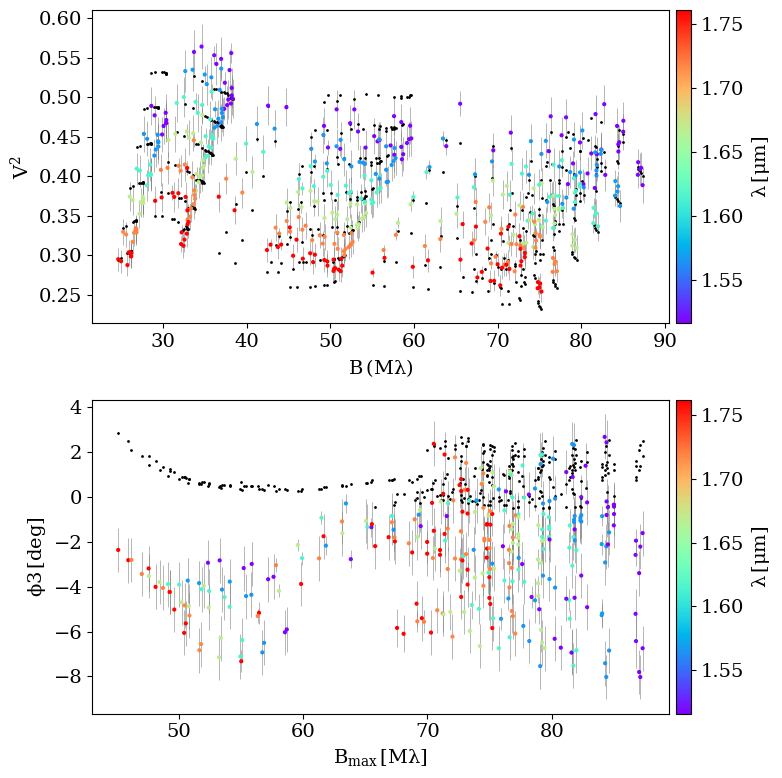

In [7]:
plot_observable_predicitons_model(oidata, model)

## Inference using nested sampling

`Blackjax` sampler APIs typically expect log-likelihood and prior functions which just
take in a vector of parameter values, passed as a 1D JAX array. Since we're dealing
with both free and fixed parameters for our models (e.g. the central wavelength `wave0`),
this requires us to do some more manual work. The azimuthal modulation amplitudes and
position angles, for example, are defined in the model as single arrays `az_amps` and
`az_pas` (for computational reasons). As a result, we'll treat each modulation as 
a separate parameter in our top-level code, but we'll have to concatenate them back
into these single arrays inside our data log-likelihood function. Using a more extensive
probabilistic programming framework like `numpyro` to do our sampling would make this a
little less involved. Nevertheless, we wouldn't have access
to the nested sampling algorithm we wish to showcase here, which is useful for 
exploration of potentially multimodal posterior landscapes, where `numpyro`'s HMC-based
algorithms could easily get stuck.


In [ ]:
# Fixed parameter values. Note that due to the layout of the internal calculations, all
# azimuthal modulations must be either free, or all fixed.
PARAMS_FIXED = {"si_p": -3.166, "wave0": 1.65e-6}

# Free parameters, denoted by the uniform prior range they cover.
PARAM_RANGE_DICT = {
    "flux_p": (0.40, 0.80),
    "ud_p": (0.0, 1.2),
    "dra_p": (-3.0, 3.0),
    "ddec_p": (-3.0, 3.0),
    "flux_s": (0.01, 0.25),
    "dra_s": (-3.0, 3.0),
    "ddec_s": (-3.0, 3.0),
    "si_s": (-4.0, 10.0),
    "diam_rim": (11.0, 16.0),  # Diameter of the rim in milliarcseconds.
    "fwhm_rim": (0.5, 5.0),  # Gaussian FWHM of the rim in milliarcseconds.
    "inc_rim": (0.0, 45.0),
    "pa_rim": (0.0, 180.0),
    "si_rim": (-4.0, 6.0),
    "flux_bkg": (0.0, 20.0),
    "si_bkg": (-4.0, 10.0),
    "az_amp1": (0.0, 1.0),
    "az_pa1": (0.0, 360.0),
    "az_amp2": (0.0, 1.0),
    "az_pa2": (0.0, 180.0),
    # "az_amp3": (0.0, 1.0),
    # "az_pa3": (0.0, 120.0),
    # "az_amp4": (0.0, 1.0),
    # "az_pa4": (0.0, 90.0),
    # "az_amp5": (0.0, 1.0),
    # "az_pa5": (0.0, 72.0),
}

# TODO: DATA DICTIONARY STRUCTURE GIVES THE MODEL HIERARCHY OF LIKELIHOOD FACTORS.
# THEN WE WILL SEARCH FOR MODEL PARAMETERS IN MODEL PARAM DICT BASED ON PREFIX. FOR
# EACH DATASET, WE START BY CONSIDERING FIRST PARAMETERS WITHOUT A PREFIX, THEN THOSE
# WITH A PREFIX GOING DOWN IN ORDER OF THE MODEL HIERARCHY TREE. IT'S ALWAYS THE LATEST
# PREFIX VALUE THAT COUNTS, I.E. THE DEEPEST LEVEL WHERE THE PARAMETER CAN BE FOUND.
# THE FIXED PARAMETER TREE WILL BE EXACTLY THE SAME!

In [ ]:
# Function to calculate data log-likelihood, wrapping around DrPangloss' loglike
# function. The azimuthal modulation amplitudes and phases need to be treated a bit
# differently, as for computational reasons they're passed as one big array to construct
# model objects. `params_free` and `params_fixed` are just dictionaries
def eval_model_loglike(params_free, params_fixed, data_obj, model_class):
    # Concatenate az_amp and az_pa parameters into single array before calling model
    # log-likelihood.
    params_free = dict_merge_az_amp_and_az_pa(params_free)
    params_fixed = dict_merge_az_amp_and_az_pa(params_fixed)

    # Merge free and fixed parameters into one consistent parameter set.
    params_dict = {**params_free, **params_fixed}
    # print(f"CONSIDERING THE FOLLOWING PARAM DICT: {params_dict}")

    # Pass parameter values and names into loglike.
    val = loglike(
        params_dict.values(), params_dict.keys(), data_obj, model_class
    )

    return val


# Fix all function values except the structure of free parameter values, so Blackjax
# samplers can accept our function.
loglikelihood_fn = Partial(
    eval_model_loglike,
    params_fixed=PARAMS_FIXED,
    data_obj=oidata,
    model_class=BinaryGaussianRimModel,
)


# Parameters for input into spinOS orbital fitting (needs semimajor/minor axis of
# error ellipse as well as the PA of the ellipse). For this, we need the error
# ellipse standard deviation along the major and minor axis as well as its PA.
def calc_pos_err_maj_min_pa(std_x, std_y, corr_xy):
    # Covariance matrix.
    cov_xy = corr_xy * std_x * std_y
    cov = jnp.array([[std_x**2, cov_xy], [cov_xy, std_y**2]])
    eigenvals, _ = jnp.linalg.eig(cov)
    idx = jnp.argsort(eigenvals)
    sorted_eigenvals = eigenvals[idx]
    err_ell_pa = 0.5 * jnp.atan2(2 * cov_xy, std_x**2 - std_y**2) * RAD2DEG
    std_min = jnp.sqrt(sorted_eigenvals[0]).astype(jnp.float32)
    std_maj = jnp.sqrt(sorted_eigenvals[1]).astype(jnp.float32)
    return std_maj, std_min, err_ell_pa

In [ ]:
# RNG key.
master_key = jax.random.key(seed=232390)

# Some algorithm hyperparameters
NLIVE = 2000
NDEAD = NLIVE // 10
NINSTEP = len(PARAM_RANGE_DICT) * 3

# Create initial point sample and function to calculate log-prior. Luckily,
# the nested sampling implementation provides a nice wrapper for this for uniform
# priors.
master_key, samples_init_key = jax.random.split(master_key, 2)
samples_init, logprior_fn = blackjax.ns.utils.uniform_prior(
    samples_init_key, NLIVE, PARAM_RANGE_DICT
)

In [ ]:
algo = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=NDEAD,
    num_inner_steps=NINSTEP,
)

live = algo.init(samples_init)
step = jax.jit(algo.step)

dead_points = []

# Run until logZ difference falls below chosen threshold (i.e. estimated remaining
# evidence in live points is < 1e-* of estimate accumulated so far).
with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not live.integrator.logZ_live - live.integrator.logZ < -3:
        master_key, subkey = jax.random.split(master_key)
        live, dead = step(subkey, live)
        dead_points.append(dead)
        pbar.update(NDEAD)
# Consume the final live points into one final nested stampling state
nsstate_final = finalise(live, dead_points)

In [ ]:
# Load dead points into anesthetic for further analysis.
samples_all = anesthetic.NestedSamples(
    data=nsstate_final.particles.position,
    logL=nsstate_final.particles.loglikelihood,
    logL_birth=nsstate_final.particles.loglikelihood_birth,
)

# Calculate relative separation of the secondary versus the primary.
samples_all["dra_rel"] = samples_all["dra_s"] - samples_all["dra_p"]
samples_all["ddec_rel"] = samples_all["ddec_s"] - samples_all["ddec_p"]
samples_all["sep_rel"] = np.sqrt(
    samples_all["dra_rel"] ** 2 + samples_all["ddec_rel"] ** 2
)
# Flux fraction of the rim.
samples_all["flux_r"] = (
    1.0
    - samples_all["flux_p"]
    - samples_all["flux_s"]
    - samples_all["flux_bkg"]
)

# This returns a dataframe-like object with unweighted posterior points.
posterior_samples_all = samples_all.posterior_points()

# Print out universal summary info of the run
print(
    "Number of available weight-adjusted posterior samples: "
    f"{posterior_samples_all.shape[0]}."
)
print(
    f"Log-evidence: {samples_all.logZ():.1f} ± {samples_all.logZ(100).std():.1f}"
)
print(f"Effective sample size: {samples_all.neff():.0f}")

# Get dataframe with only parameters for plotting/correlation analysis. anesthetic
# usually stores additional info which we don't need anymore.
IGNORED_SAMPLE_KEYS = ["logL", "logL_birth", "nlive"]
samples = samples_all.drop(columns=IGNORED_SAMPLE_KEYS)
posterior_samples = posterior_samples_all.drop(columns=IGNORED_SAMPLE_KEYS)


# Parameter summary.
print("\nParameter estimates (median ± std; takes care of weights):")
print("-" * 40)

for col in [key for key in samples.keys() if key not in IGNORED_SAMPLE_KEYS]:
    median = samples[col].median()
    std = samples[col].std()
    print(f"{col:20s}: {median:.4f} ± {std:.4f}")

# Get median posterior parameters into a dictionary shape.
param_median_dict = {
    param: samples[param].median()
    for param in samples.keys()
    if param in PARAM_RANGE_DICT
}

# Construct median model from weighted median estimates.
final_model_param_dict = param_median_dict | PARAMS_FIXED
final_model_param_dict = dict_merge_az_amp_and_az_pa(final_model_param_dict)
model_median = BinaryGaussianRimModel(**final_model_param_dict)

# Calculate and display mean chi2 values (chi2 divided by amount of data points) of
# the median model.
chi2tot, chi2vis, chi2phi = get_mean_chi2_model(oidata, model_median)
print(f"\nMean chi2 tot for median model: {chi2tot}")
print(f"Mean chi2 vis2 for median model: {chi2vis}")
print(f"Mean chi2 cp for median model: {chi2phi}")

std_maj, std_min, err_ell_pa = calc_pos_err_maj_min_pa(
    samples["dra_rel"].std(),
    samples["ddec_rel"].std(),
    samples["dra_rel"].corr(samples["ddec_rel"]),
)

print("\nRelative astrometry estimate and error ellipse for spinOS values:")
print("-" * 40)
for col in ["dra_rel", "ddec_rel"]:
    median = samples[col].median()
    std = samples[col].std()
    print(f"{col:30s}: {median:.4f} ± {std:.4f}")
print(f"{'Error major axis (mas)':30s}: {std_maj:.4f}")
print(f"{'Error minor axis (mas)':30s}: {std_min:.4f}")
print(f"{'PA of error ellipse (deg)':30s}: {err_ell_pa:.4f}")

In [ ]:
# Display correlation matrix.
corr_matrix = posterior_samples.corr()
columns = posterior_samples.columns

fig, ax = plt.subplots(figsize=(12, 9))

# Display data as an image (imshow)
cax = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

# Add a color bar legend
fig.colorbar(cax, ax=ax, pad=0.01)

# Set axis labels using column headers
ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha="right")
ax.set_yticklabels(columns)

# Loop to annotate the cells with text values
for i in range(len(columns)):
    for j in range(len(columns)):
        val = corr_matrix.values[i, j]
        # Choose text color (black or white) based on background for contrast
        text_color = "white" if abs(val) > 0.5 else "black"
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=7,
        )

plt.title("Correlation heatmap", pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 1D posteriors (we ignore some keys that `anesthetic` adds to the nested samples
# dataframe, but which we're not interested in).
nplots = len([key for key in samples.keys() if key not in IGNORED_SAMPLE_KEYS])
ncol = 4
nrow = nplots // ncol + 1

fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow))
axes = axes.flatten()

# 1D histograms.
param_names = [key for key in samples.keys() if key not in IGNORED_SAMPLE_KEYS]
for i, param in enumerate(param_names):
    dim_samples = posterior_samples[param].to_numpy()
    axes[i].hist(dim_samples, bins=20, color="lightgrey", edgecolor="black")
    axes[i].set_xlabel(param)

# Remove excessive plot axes.
for i in range(len(param_names), ncol * nrow):
    axes[i].remove()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.hexbin(
    posterior_samples["dra_rel"],
    posterior_samples["ddec_rel"],
    cmap="bone_r",
    gridsize=20,
)
ax.scatter(
    0.0,
    0.0,
    marker="*",
    s=128,
    color="gold",
    edgecolors="black",
)
ax.scatter(
    samples["dra_rel"].median(),
    samples["ddec_rel"].median(),
    marker="2",
    s=64,
    color="lime",
)

err_ellipse = Ellipse(
    xy=(samples["dra_rel"].median(), samples["ddec_rel"].median()),
    width=2 * std_min,
    height=2 * std_maj,
    angle=err_ell_pa + 90,
    edgecolor="lime",
    facecolor="none",
    linewidth=1.5,
)

ax.invert_xaxis()
ax.add_patch(err_ellipse)
ax.set_xlabel(r"$\Delta \mathregular{RA_{rel}} \, \mathregular{[mas]}$")
ax.set_ylabel(r"$\Delta \mathregular{Dec_{rel}} \, \mathregular{[mas]}$")
ax.set_title("Relative secondary position")
plt.show()

In [ ]:
# Make a plot of the final rim model.
NPIX = 600  # Number of pixels along the field-of-view.
PS = 0.05  # Pixelscale in milliarcseconds.
FOV = NPIX * PS

EXTENT = (
    FOV / 2,
    -FOV / 2,
    -FOV / 2,
    FOV / 2,
)

# Extract cube of images from posterior samples to get image significance.
nsamples = posterior_samples[param_names[0]].size
imgs = []
for i in range(nsamples):
    model_param_dict = {}
    for param in PARAM_RANGE_DICT.keys():
        model_param_dict[param] = posterior_samples[param].iloc[i]
    model_param_dict = model_param_dict | PARAMS_FIXED
    model_param_dict = dict_merge_az_amp_and_az_pa(model_param_dict)
    model = BinaryGaussianRimModel(**model_param_dict)
    imgs.append(model.get_img(npix=NPIX, ps=PS))
imgs = jnp.stack(imgs, axis=0)

In [ ]:
# Set significance thresholds for image plots.scipy
SIGMA_LEVEL = 5
TAIL_PROB = scipy.stats.norm.sf(SIGMA_LEVEL)

# Calculate median image and deviations/quantiles.
img_median = jnp.median(imgs, axis=0)
img_std = jnp.std(imgs, axis=0)
img_sig = jnp.maximum(img_median / img_std, 0)
img_ql = jnp.quantile(imgs, q=TAIL_PROB, axis=0)
img_qu = jnp.quantile(imgs, q=1 - TAIL_PROB, axis=0)

In [ ]:
# %matplotlib qt
# gui = samples.gui()
# plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1)
imsh = ax.imshow(img_sig, extent=EXTENT)

# Add stars.
ax.scatter(
    0.0,
    0.0,
    marker=".",
    s=16,
    color="white",
)
ax.scatter(
    model_median.dra_p,
    model_median.ddec_p,
    marker="*",
    s=128,
    color="gold",
    edgecolors="black",
)
ax.scatter(
    model_median.dra_s, model_median.ddec_s, marker="2", s=64, color="lime"
)

ax.set_xlabel(r"$\Delta \mathregular{RA} \, \mathregular{[mas]}$")
ax.set_ylabel(r"$\Delta \mathregular{Dec} \, \mathregular{[mas]}$")

# # Draw contours.
# if i == 0:
#     ax.contour(
#         rim_img / jnp.max(rim_img),
#         levels=[0.1, 0.3, 0.5, 0.7, 0.9],
#         colors="white",
#         linewidths=0.5,
#         extent=extent,
#         alpha=0.5,
#     )


fig.colorbar(imsh, label=r"$\sigma$ significance", pad=0.015, aspect=20)
plt.show()

In [ ]:
# Get an image of the rim (normalized so sum of pixels is one).
rim_img = model_median.get_img(npix=NPIX, ps=PS)

fig = plt.figure(figsize=(3 * 5, 5))
axes = ImageGrid(
    fig,
    111,  # Similar to subplot(111)
    nrows_ncols=(1, 3),  # A row of 3 plots
    axes_pad=0.40,  # Padding between plots
    cbar_mode="single",  # Allocate exactly one colorbar slot
    cbar_location="right",  # Position it on the right side of the row
    cbar_pad=0.15,  # Padding between the last plot and colorbar
    cbar_size="5%",  # Colorbar width relative to a single plot
)

# Plot image.
for i, ax in enumerate(axes):
    if i == 0:
        rim_img = img_median
        label = "Median"
    elif i == 1:
        rim_img = img_ql
        label = rf"Lower quantile $({SIGMA_LEVEL}\sigma)$"
    elif i == 2:
        rim_img = img_qu
        label = rf"Upper quantile $({SIGMA_LEVEL}\sigma)$"
    im = ax.imshow(
        rim_img / jnp.max(rim_img),
        extent=EXTENT,
        cmap="inferno",
    )
    # Add stars.
    ax.scatter(
        0.0,
        0.0,
        marker=".",
        s=16,
        color="white",
    )
    ax.scatter(
        model_median.dra_p,
        model_median.ddec_p,
        marker="*",
        s=128,
        color="gold",
        edgecolors="black",
    )
    ax.scatter(
        model_median.dra_s, model_median.ddec_s, marker="2", s=64, color="lime"
    )
    ax.set_title(label)

    if i == 2:
        cbar = axes.cbar_axes[0].colorbar(im, label="Intensity")

    ax.set_xlabel(r"$\Delta \mathregular{RA} \, \mathregular{[mas]}$")
    ax.set_ylabel(r"$\Delta \mathregular{Dec} \, \mathregular{[mas]}$")

plt.show()

In [ ]:
# Plot model predictions against observed data.
plot_observable_predicitons_model(oidata, model_median)